# **CLINICAL APPOINTMENT NO- SHOW PREDICTION**



# Dataset Description
## Dataset Source
Hospital Appointment No-Show Prediction Dataset  
Source: Kaggle  
Link: https://www.kaggle.com/datasets/miadul/hospital-appointment-no-show-prediction-dataset/data  

The dataset contains 5,000 synthetic hospital appointment records designed to predict whether a patient will miss a scheduled appointment.

Target Variable:
- no_show (0 = Show, 1 = No-Show)

------------------------------------------------------------

## Input Features and Description

1. patient_id  
   Unique identifier for each patient record.

2. age  
   Age of the patient (numerical).

3. gender  
   Gender of the patient (Male / Female).

4. city_type  
   Type of residential area (Urban / Suburban / Other).

5. distance_km  
   Distance between patient’s residence and hospital (in kilometers).

6. travel_time_min  
   Estimated travel time to hospital (in minutes).

7. appointment_day  
   Day of the week when appointment is scheduled.

8. appointment_time_slot  
   Time slot of appointment (Morning / Afternoon / Evening).

9. department  
   Medical department or specialty (Cardiology, Pediatrics, etc.).

10. waiting_days  
    Number of days between booking date and appointment date.

11. previous_appointments  
    Total number of previous hospital appointments attended.

12. previous_no_shows  
    Number of previous missed appointments.

13. diabetes  
    Binary indicator (0 = No, 1 = Yes).

14. hypertension  
    Binary indicator (0 = No, 1 = Yes).

15. chronic_disease  
    Binary indicator (0 = No, 1 = Yes).

16. sms_reminder  
    Indicates whether SMS reminder was sent (0 = No, 1 = Yes).

17. email_reminder  
    Indicates whether email reminder was sent (0 = No, 1 = Yes).

18. num_reminders  
    Total number of reminders sent to the patient.

19. employment_status  
    Employment category (Employed / Student / Other).

20. education_level  
    Education level (Primary / Secondary / Higher).

21. insurance_status  
    Insurance coverage status (Insured / Uninsured).

22. rainy_day  
    Indicates whether appointment day had rainfall (0 = No, 1 = Yes).

23. public_holiday  
    Indicates whether appointment day was a public holiday (0 = No, 1 = Yes).

------------------------------------------------------------

## Output Variable

24. no_show  
    0 → Patient attended the appointment  
    1 → Patient missed the appointment  

------------------------------------------------------------

Objective:
Build a supervised machine learning classification model to predict the probability of a patient missing their scheduled appointment using demographic, medical, behavioral, communication, and environmental features.

### 📌 **1. IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

primary_color = "#2E86C1"
secondary_color = "#117A65"
warning_color = "#C0392B"
neutral_color = "#7B7D7D"

sns.set_palette([primary_color, secondary_color, warning_color])

### **📌 2. LOAD DATA**

In [ ]:
df = pd.read_csv("hospital_appointment_no_show_5000.csv")

### **📌 3. DATASET INFO**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

Shape: (5000, 24)

Columns:
 ['patient_id', 'age', 'gender', 'city_type', 'distance_km', 'travel_time_min', 'appointment_day', 'appointment_time_slot', 'department', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'employment_status', 'education_level', 'insurance_status', 'rainy_day', 'public_holiday', 'no_show']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    4610 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            4612 non-null   float64
 5   travel_time_min        4584 non-null   float64
 6   appointment_day        5000 non-null   objec

In [ ]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,5000.000000,4610.000000,4612.000000,4584.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,4560.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,39.643167,8.310169,41.967779,6.990600,2.005600,0.40180,0.186200,0.287200,0.476400,0.706800,0.401535,1.404200,0.207000,0.099800,0.50000
std,1443.520003,14.925693,4.604878,23.271754,2.671917,1.423227,0.64687,0.389307,0.452501,0.499493,0.455275,0.490263,0.814466,0.405196,0.299763,0.50005
min,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1250.750000,30.000000,4.800000,23.600000,5.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000
50%,2500.500000,40.000000,8.100000,40.700000,7.000000,2.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.50000
75%,3750.250000,49.750000,11.400000,57.525000,9.000000,3.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.00000
max,5000.000000,90.000000,30.400000,128.400000,21.000000,9.000000,5.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.00000


In [ ]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','bool']).columns

print("Numerical Columns:", list(numerical_cols))
print("\nCategorical Columns:",list(categorical_cols))

Numerical Columns: ['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'rainy_day', 'public_holiday', 'no_show']

Categorical Columns: ['gender', 'city_type', 'appointment_day', 'appointment_time_slot', 'department', 'employment_status', 'education_level', 'insurance_status']


In [ ]:
target = "no_show" if "no_show" in df.columns else None
target

'no_show'

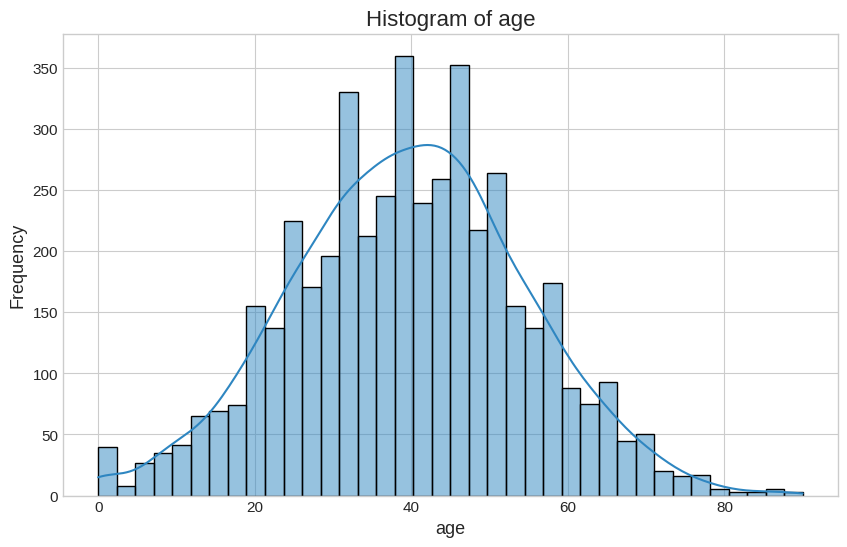

In [ ]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title(f"Histogram of {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Frequency')

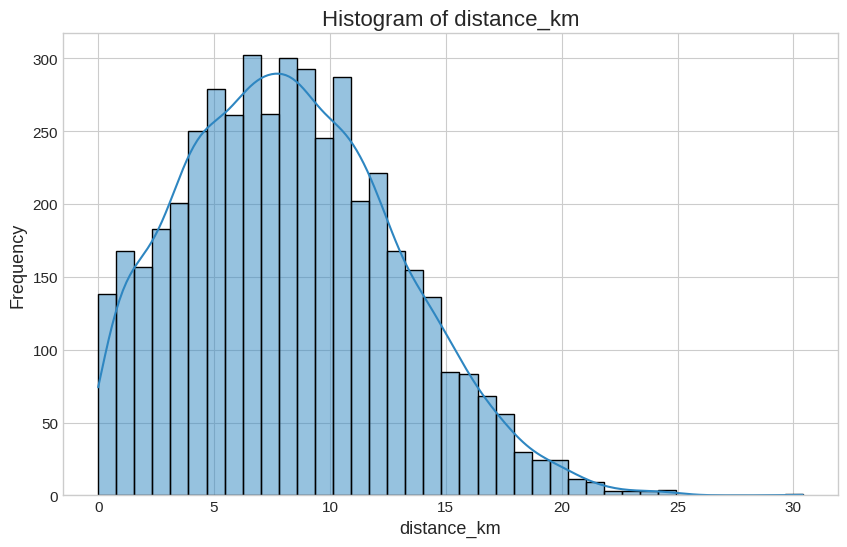

In [ ]:
plt.figure()
sns.histplot(df['distance_km'], kde=True)
plt.title(f"Histogram of {'distance_km'}")
plt.xlabel('distance_km')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

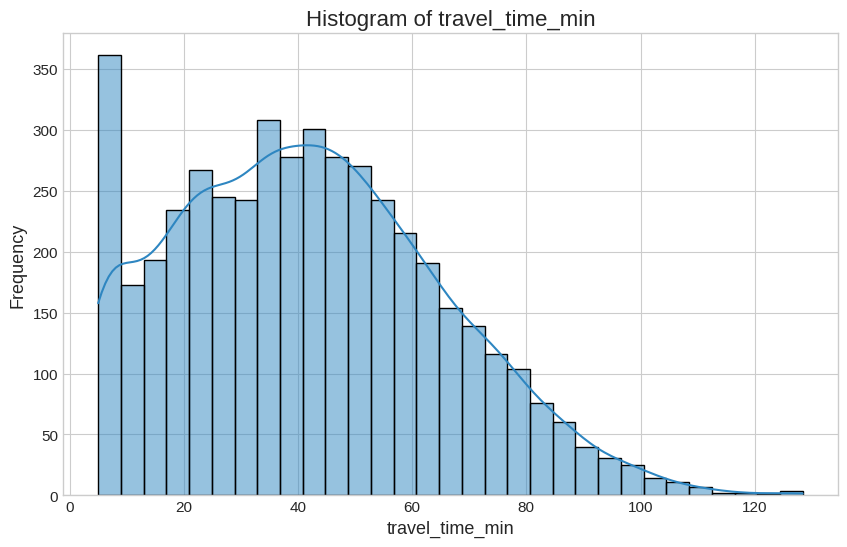

In [ ]:
plt.figure()
sns.histplot(df['travel_time_min'], kde=True)
plt.title(f"Histogram of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

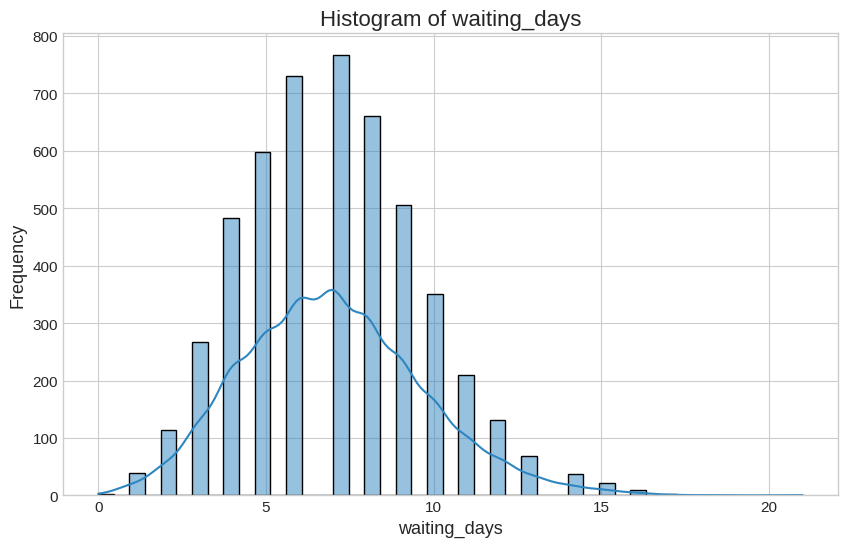

In [ ]:
plt.figure()
sns.histplot(df['waiting_days'], kde=True)
plt.title(f"Histogram of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

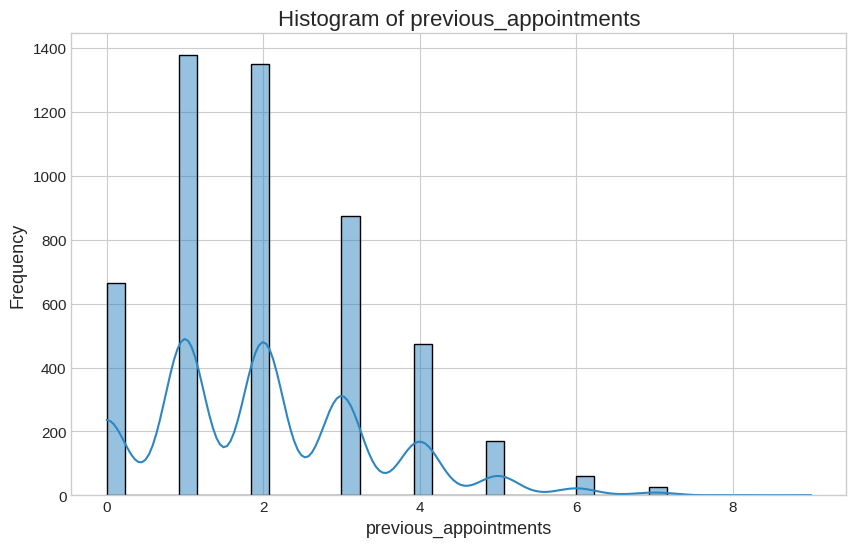

In [ ]:
plt.figure()
sns.histplot(df['previous_appointments'], kde=True)
plt.title(f"Histogram of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

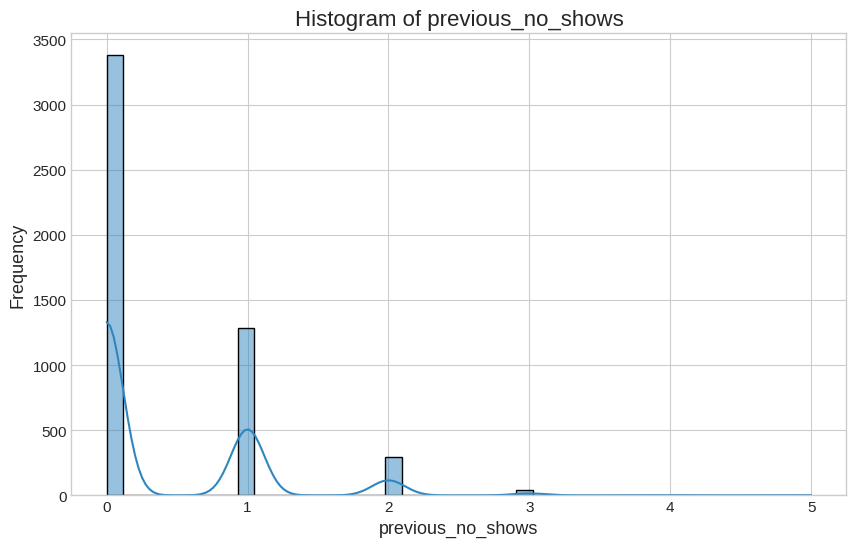

In [ ]:
plt.figure()
sns.histplot(df['previous_no_shows'], kde=True)
plt.title(f"Histogram of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.ylabel("Frequency")

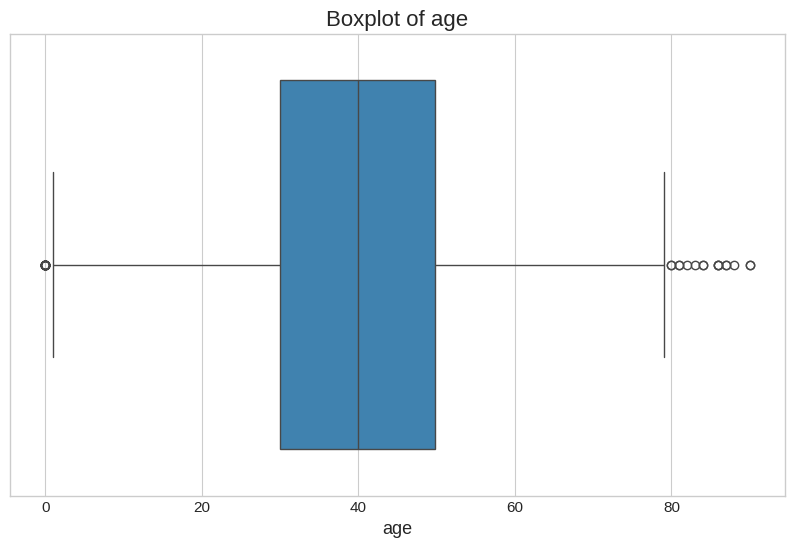

In [ ]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title(f"Boxplot of {'age'}")
plt.xlabel('age')
plt.show()

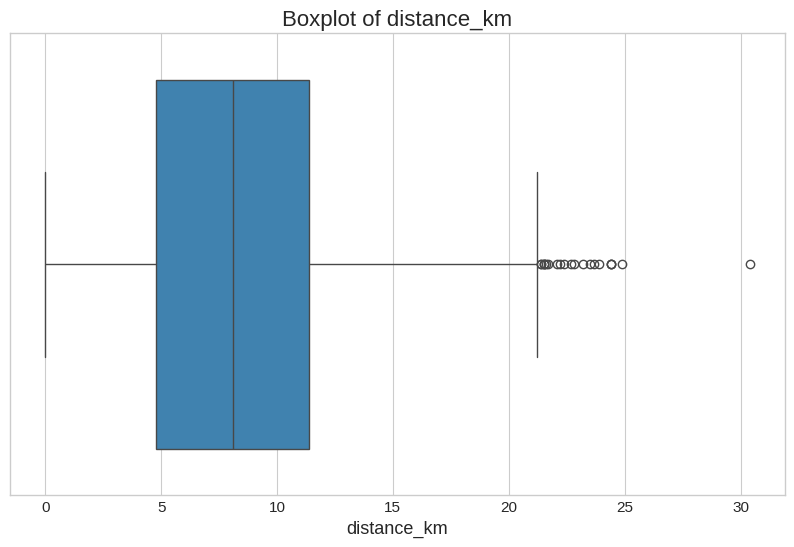

In [ ]:
plt.figure()
sns.boxplot(x=df['distance_km'])
plt.title(f"Boxplot of {'distance_km'}")
plt.xlabel('distance_km')
plt.show()

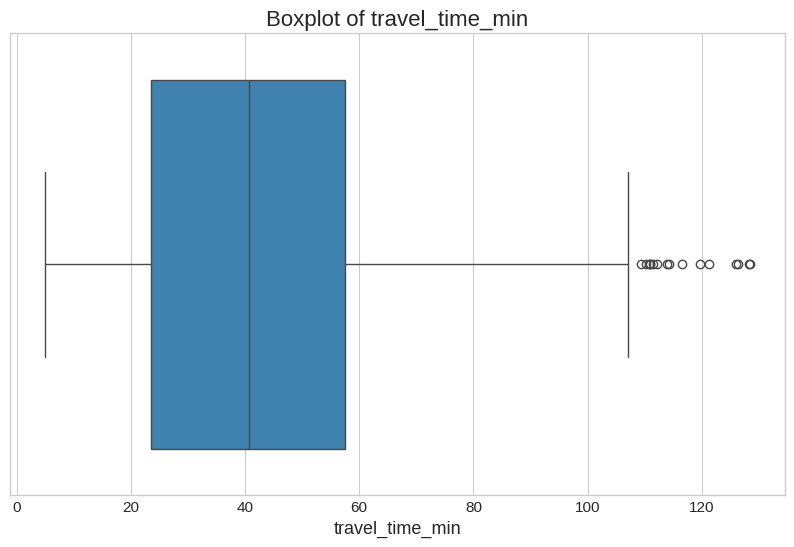

In [ ]:
plt.figure()
sns.boxplot(x=df['travel_time_min'])
plt.title(f"Boxplot of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.show()

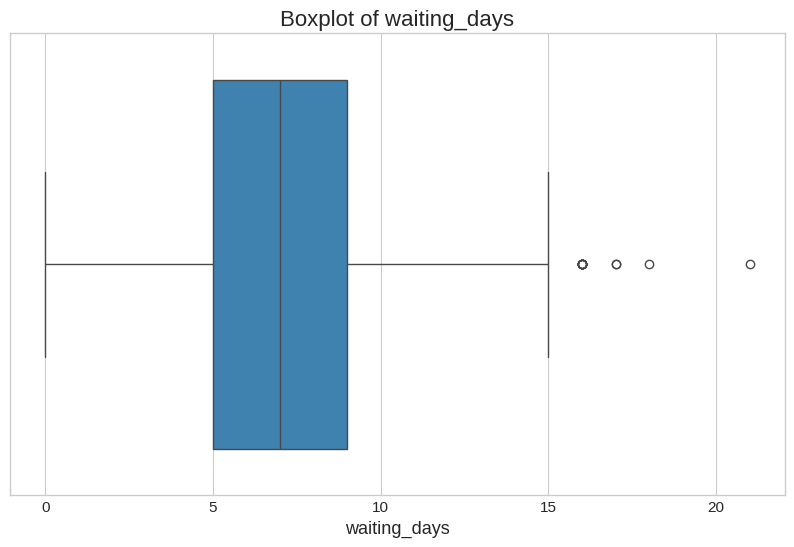

In [ ]:
plt.figure()
sns.boxplot(x=df['waiting_days'])
plt.title(f"Boxplot of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.show()

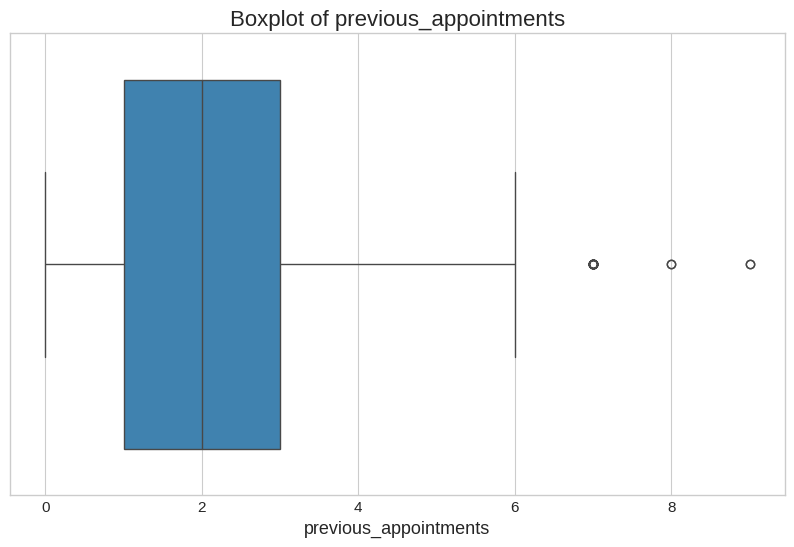

In [ ]:
plt.figure()
sns.boxplot(x=df['previous_appointments'])
plt.title(f"Boxplot of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.show()

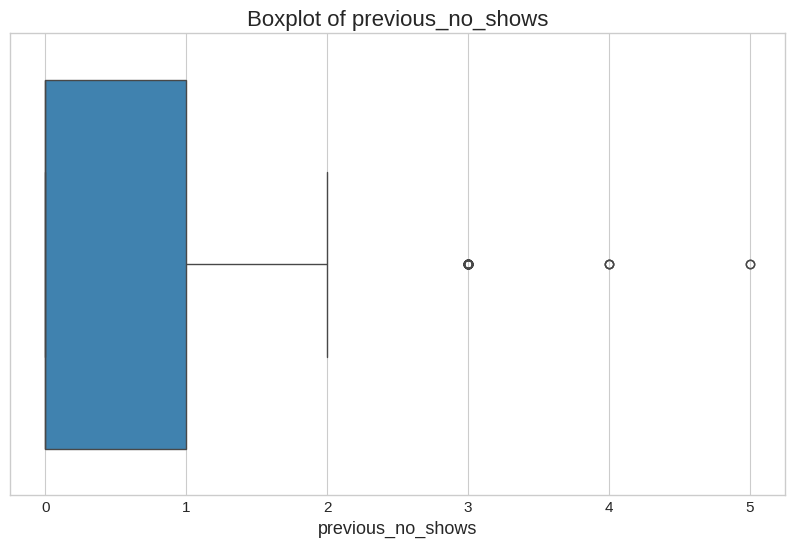

In [ ]:
plt.figure()
sns.boxplot(x=df['previous_no_shows'])
plt.title(f"Boxplot of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.show()

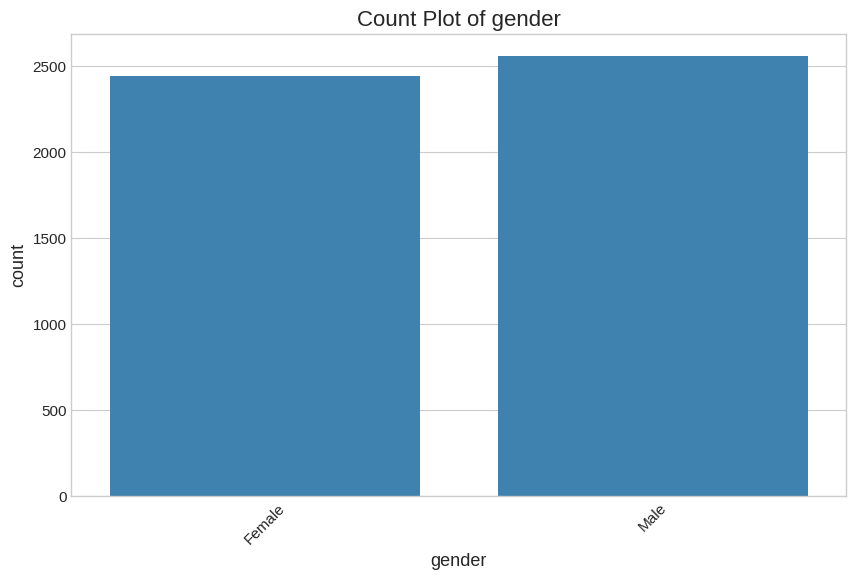

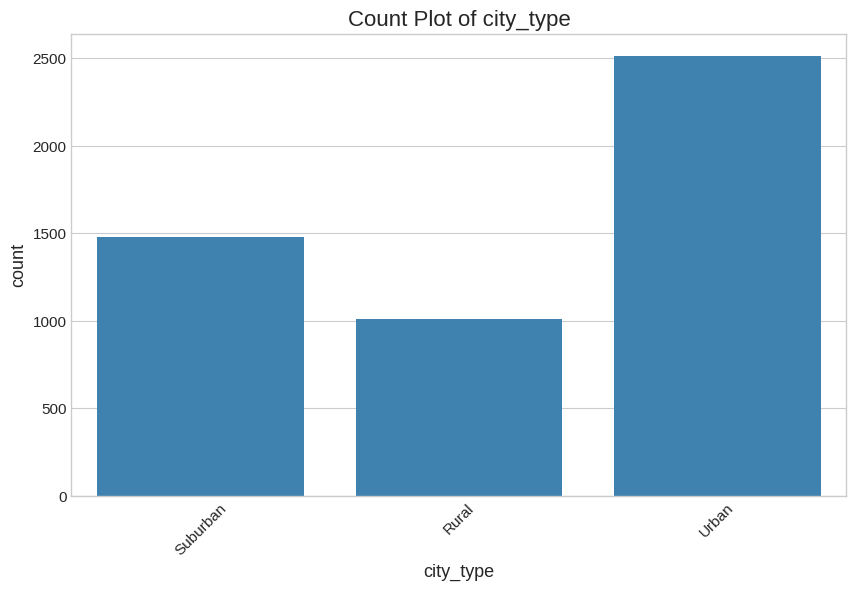

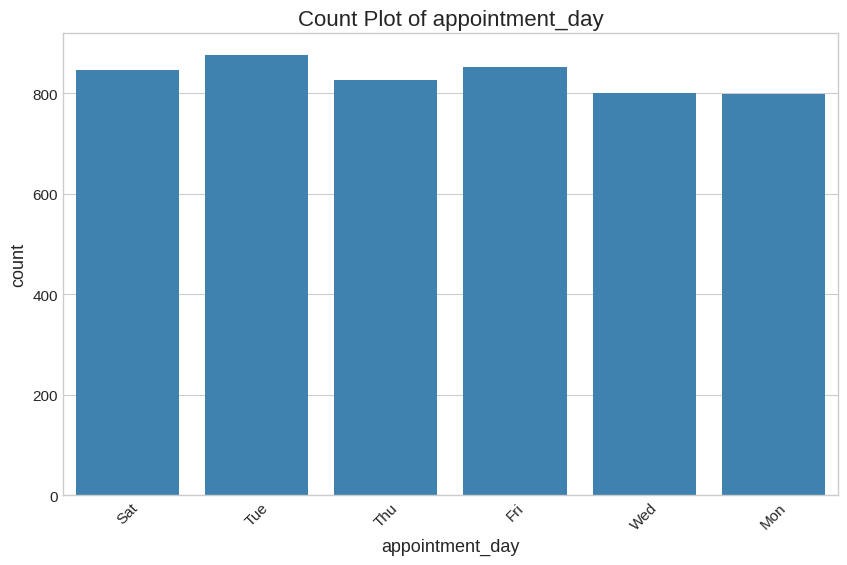

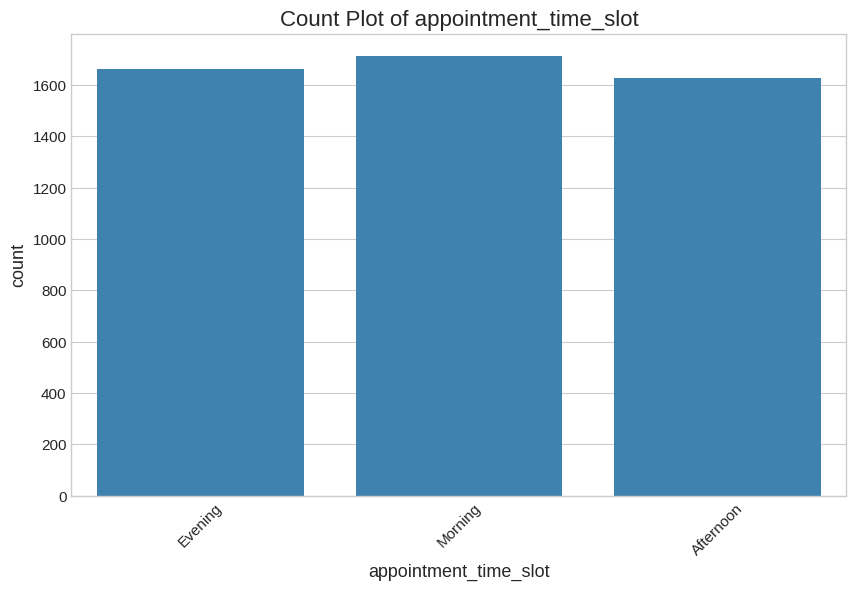

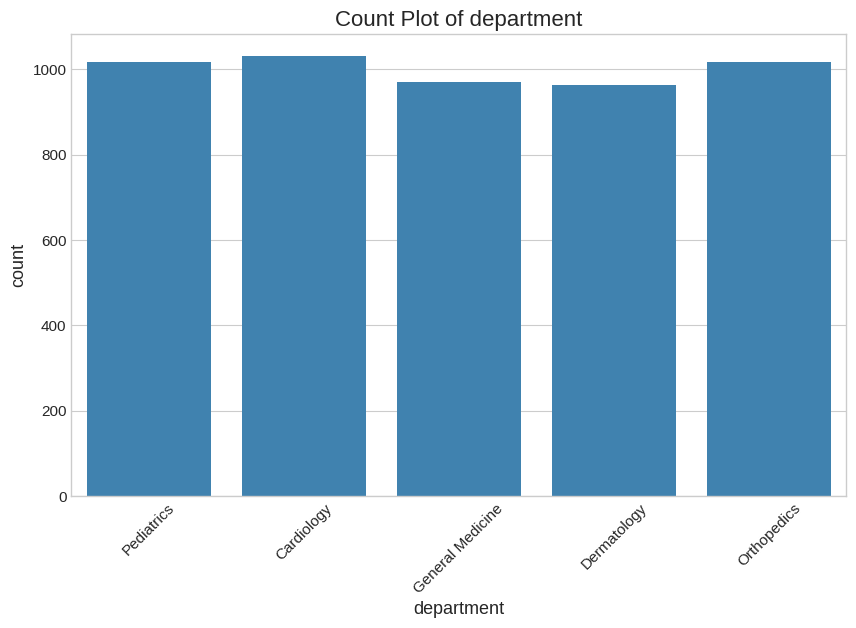

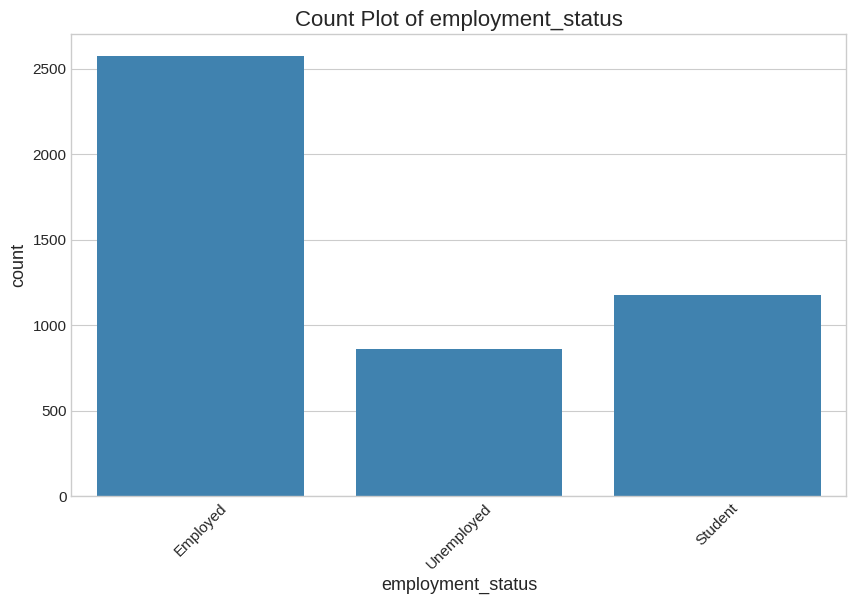

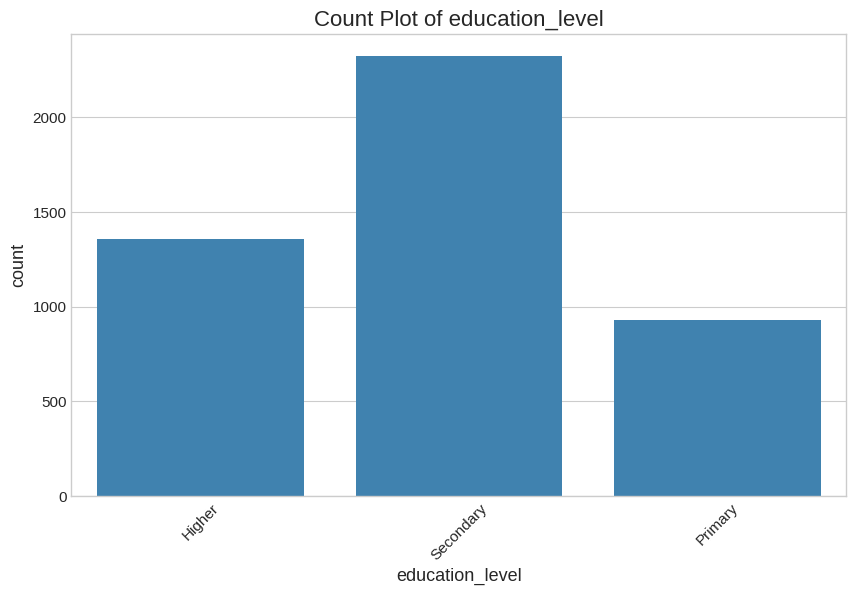

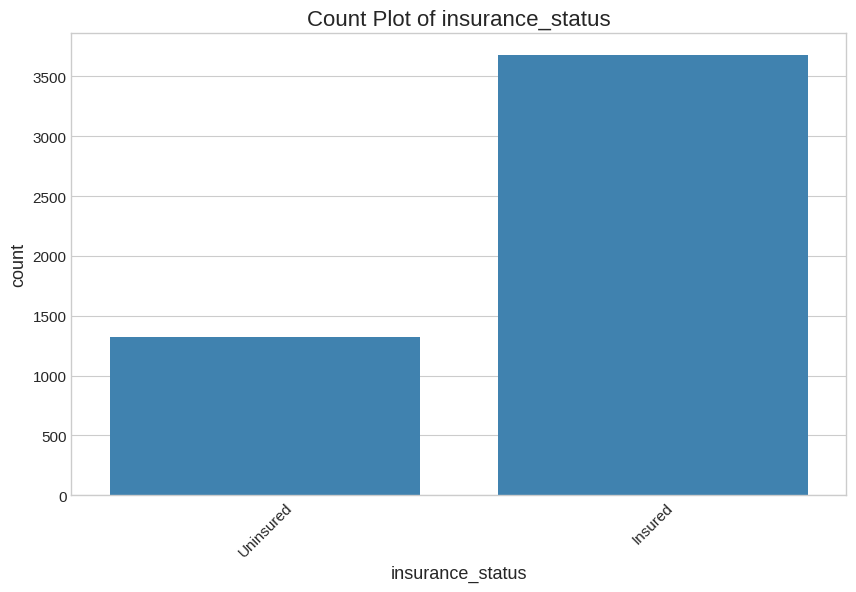

In [ ]:
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

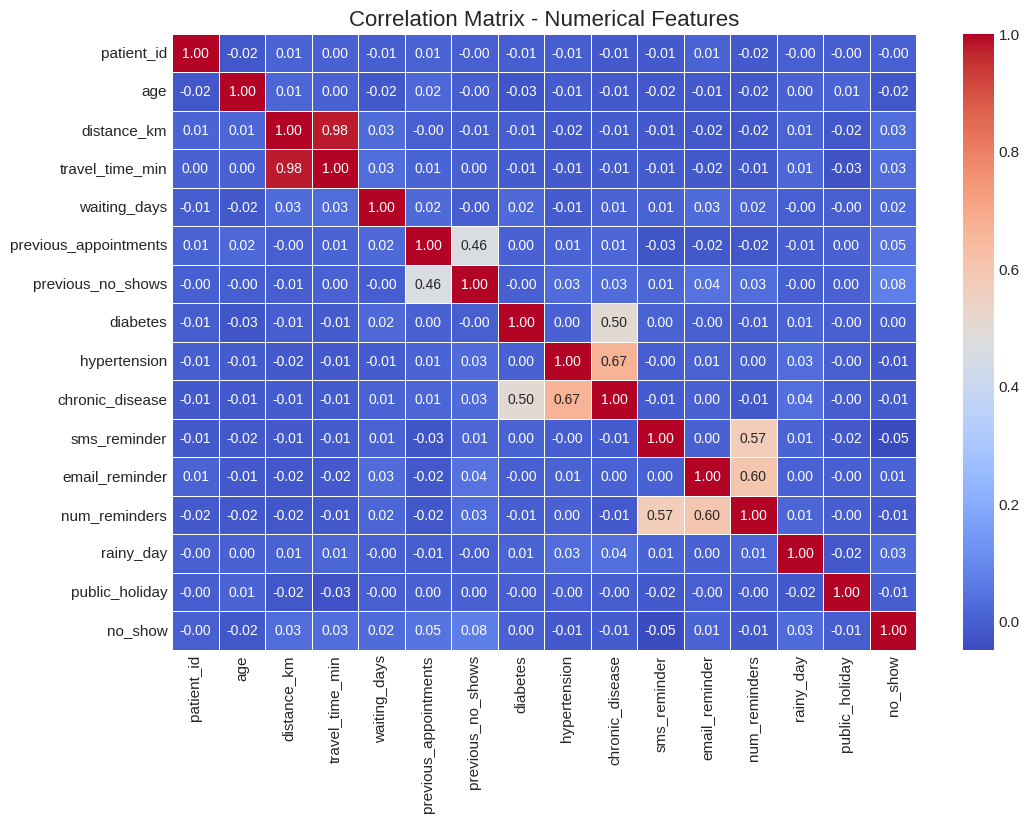

In [ ]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

### **📌 4. FEATURE ENGINEERING**

Required Features:

Lead Time, History, Day/Time, Department

In [ ]:
df.drop("patient_id", axis=1, inplace=True)

In [ ]:
df.rename(columns={"waiting_days": "lead_time"}, inplace=True)

In [ ]:
df["no_show_ratio"] = df["previous_no_shows"] / (df["previous_appointments"] + 1)

### **📌 5. DEFINE FEATURES AND TARGET**

In [ ]:
X = df.drop("no_show", axis=1)
y = df["no_show"]

### **📌 6. SPLIT DATA**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 , stratify=y
)

### **📌 7. PREPROCESSING PIPELINE**

In [ ]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In [ ]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'distance_km', 'travel_time_min', 'lead_time',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show_ratio'],
      dtype='object')
Categorical Columns: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


### **7.1. Handle Missing Values**

In [ ]:
X_train.isnull().sum()

,0
age,320
gender,0
city_type,0
distance_km,289
travel_time_min,316
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [ ]:
X_test.isnull().sum()

,0
age,70
gender,0
city_type,0
distance_km,99
travel_time_min,100
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [ ]:
for col in numerical_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

### **7.2. Encoding Categorical Variables**

We use One-Hot Encoding for all categorical variables.

Why not Label Encoding?

Because:
Logistic Regression assumes numeric order.

In [ ]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

### **7.3. StandardScaler**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **📌 8. MODEL TRAINING**

### **8.1. LOGISTIC REGRESSION**

In [ ]:
results = []

In [ ]:
logistic_model = LogisticRegression(max_iter=500)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [ ]:
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("🔷 Logistic Regression Results")
print("Accuracy :", acc_log)
print("Precision:", prec_log)
print("Recall   :", rec_log)
print("F1 Score :", f1_log)
print("ROC-AUC  :", auc_log)

🔷 Logistic Regression Results
Accuracy : 0.53
Precision: 0.5315126050420168
Recall   : 0.506
F1 Score : 0.5184426229508197
ROC-AUC  : 0.5455720000000001


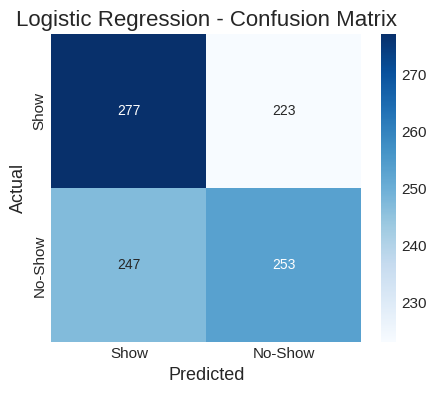

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc_log,
    "Precision": prec_log,
    "Recall": rec_log,
    "F1": f1_log,
    "ROC-AUC": auc_log
})

### **8.2. DECISION TREE**

In [ ]:
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("🔷 Decision Tree Results")
print("Accuracy :", acc_tree)
print("Precision:", prec_tree)
print("Recall   :", rec_tree)
print("F1 Score :", f1_tree)
print("ROC-AUC  :", auc_tree)

🔷 Decision Tree Results
Accuracy : 0.507
Precision: 0.5071868583162218
Recall   : 0.494
F1 Score : 0.5005065856129686
ROC-AUC  : 0.507


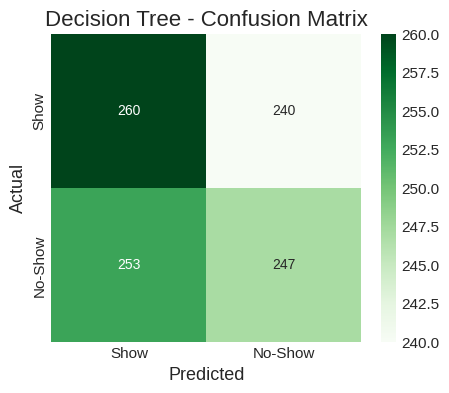

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": acc_tree,
    "Precision": prec_tree,
    "Recall": rec_tree,
    "F1": f1_tree,
    "ROC-AUC": auc_tree
})

### **8.3. RANDOM FOREST**

In [ ]:
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("🔷 Random Forest Results")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", auc_rf)

🔷 Random Forest Results
Accuracy : 0.51
Precision: 0.5101214574898786
Recall   : 0.504
F1 Score : 0.5070422535211268
ROC-AUC  : 0.5355820000000001


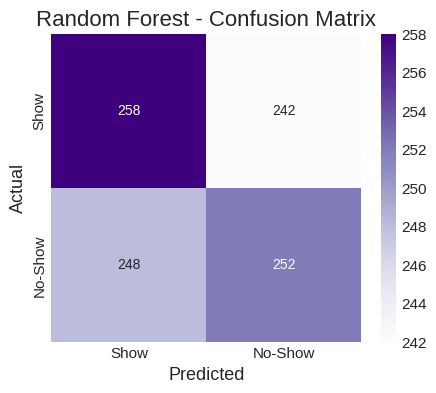

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1": f1_rf,
    "ROC-AUC": auc_rf
})

### **📌 9. COMPARE ALL MODELS**

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.530,0.531513,0.506,0.518443,0.545572
1,Decision Tree,0.507,0.507187,0.494,0.500507,0.507000
2,Random Forest,0.510,0.510121,0.504,0.507042,0.535582


### Test

In [ ]:
df.drop("distance_km", axis=1, inplace=True)

In [ ]:
df["high_risk_history"] = (df["previous_no_shows"] >= 1).astype(int)

In [ ]:
df["elderly"] = (df["age"] >= 60).astype(int)
df["chronic_elderly"] = ((df["chronic_disease"] == 1) & (df["age"] >= 60)).astype(int)

In [ ]:
df["long_wait"] = (df["lead_time"] > 7).astype(int)

In [ ]:
df["reminder_intensity"] = df["num_reminders"] / (df["lead_time"] + 1)

In [ ]:
df["history_wait_interaction"] = df["previous_no_shows"] * df["lead_time"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [ ]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred_adjusted = (y_prob_rf >= threshold).astype(int)

In [ ]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("🔷 Random Forest (Threshold = 0.5)")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", auc_rf)

🔷 Random Forest (Threshold = 0.5)
Accuracy : 0.546
Precision: 0.55
Recall   : 0.506
F1 Score : 0.5270833333333333
ROC-AUC  : 0.555596


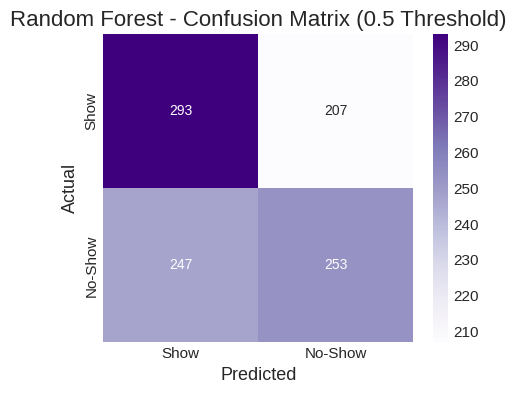

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf,
            annot=True,
            fmt="d",
            cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix (0.5 Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib

joblib.dump(random_forest_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [ ]:
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import datetime, timedelta
import plotly.graph_objects as go
import plotly.express as px

# Page configuration
st.set_page_config(
    page_title="Hospital No-Show Predictor",
    page_icon="🏥",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
    <style>
    .main {
        padding: 0rem 1rem;
    }
    .stAlert {
        padding: 1rem;
        border-radius: 0.5rem;
    }
    .metric-card {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 0.5rem;
        margin: 0.5rem 0;
    }
    h1 {
        color: #1f77b4;
    }
    .prediction-box {
        padding: 2rem;
        border-radius: 1rem;
        text-align: center;
        font-size: 1.5rem;
        font-weight: bold;
        margin: 1rem 0;
    }
    .high-risk {
        background-color: #ffebee;
        color: #c62828;
        border: 2px solid #c62828;
    }
    .medium-risk {
        background-color: #fff3e0;
        color: #e65100;
        border: 2px solid #e65100;
    }
    .low-risk {
        background-color: #e8f5e9;
        color: #2e7d32;
        border: 2px solid #2e7d32;
    }
    </style>
""", unsafe_allow_html=True)

# Load model and scaler
@st.cache_resource
def load_model():
    try:
        model = joblib.load('model.pkl')
        scaler = joblib.load('scaler.pkl')
        return model, scaler
    except FileNotFoundError:
        st.error("⚠️ Model files not found! Please ensure 'best_no_show_model.pkl' and 'scaler.pkl' are in the same directory.")
        st.stop()

# Feature engineering function (MUST match training!)
def create_features(input_df):
    """
    Create all engineered features - MUST match exactly what was used in training
    """
    df = input_df.copy()

    # 1. BEHAVIORAL FEATURES
    df['no_show_rate'] = df['previous_no_shows'] / (df['previous_appointments'] + 1)
    df['reliability_score'] = (df['previous_appointments'] - df['previous_no_shows']) / (df['previous_appointments'] + 1)
    df['is_new_patient'] = (df['previous_appointments'] == 0).astype(int)
    df['is_frequent_patient'] = (df['previous_appointments'] > 5).astype(int)
    df['has_previous_no_show'] = (df['previous_no_shows'] > 0).astype(int)

    # 2. DISTANCE & TRAVEL FEATURES
    df['distance_km_filled'] = df['distance_km'].fillna(df['distance_km'].median())
    df['travel_time_filled'] = df['travel_time_min'].fillna(df['travel_time_min'].median())
    df['is_far'] = (df['distance_km_filled'] > df['distance_km_filled'].median()).astype(int)
    df['is_very_far'] = (df['distance_km_filled'] > df['distance_km_filled'].quantile(0.75)).astype(int)
    df['long_travel'] = (df['travel_time_filled'] > df['travel_time_filled'].median()).astype(int)
    df['very_long_travel'] = (df['travel_time_filled'] > 60).astype(int)
    df['distance_time_ratio'] = df['distance_km_filled'] / (df['travel_time_filled'] + 1)

    # 3. WAITING TIME FEATURES
    df['long_wait'] = (df['waiting_days'] > 7).astype(int)
    df['very_long_wait'] = (df['waiting_days'] > 14).astype(int)
    df['short_wait'] = (df['waiting_days'] <= 3).astype(int)

    # 4. TIMING FEATURES
    df['is_weekend'] = df['appointment_day'].isin(['Sat', 'Sun']).astype(int)
    df['is_monday'] = (df['appointment_day'] == 'Mon').astype(int)
    df['is_friday'] = (df['appointment_day'] == 'Fri').astype(int)
    df['is_midweek'] = df['appointment_day'].isin(['Tue', 'Wed', 'Thu']).astype(int)
    df['is_morning'] = (df['appointment_time_slot'] == 'Morning').astype(int)
    df['is_afternoon'] = (df['appointment_time_slot'] == 'Afternoon').astype(int)
    df['is_evening'] = (df['appointment_time_slot'] == 'Evening').astype(int)

    # 5. HEALTH CONDITION FEATURES
    df['num_conditions'] = df['diabetes'] + df['hypertension'] + df['chronic_disease']
    df['has_any_condition'] = (df['num_conditions'] > 0).astype(int)
    df['multiple_conditions'] = (df['num_conditions'] > 1).astype(int)

    # 6. REMINDER FEATURES
    df['email_reminder_filled'] = df['email_reminder'].fillna(0)
    df['total_reminders'] = df['sms_reminder'] + df['email_reminder_filled']
    df['has_multiple_reminders'] = (df['num_reminders'] > 1).astype(int)
    df['no_reminder'] = (df['num_reminders'] == 0).astype(int)
    df['has_any_reminder'] = (df['num_reminders'] > 0).astype(int)

    # 7. AGE FEATURES
    df['age_filled'] = df['age'].fillna(df['age'].median())
    df['is_child'] = (df['age_filled'] < 18).astype(int)
    df['is_young_adult'] = ((df['age_filled'] >= 18) & (df['age_filled'] < 30)).astype(int)
    df['is_adult'] = ((df['age_filled'] >= 30) & (df['age_filled'] < 50)).astype(int)
    df['is_senior'] = ((df['age_filled'] >= 50) & (df['age_filled'] < 65)).astype(int)
    df['is_elderly'] = (df['age_filled'] >= 65).astype(int)

    # 8. SOCIOECONOMIC FEATURES
    df['is_uninsured'] = (df['insurance_status'] == 'Uninsured').astype(int)
    df['is_insured'] = (df['insurance_status'] == 'Insured').astype(int)
    df['is_employed'] = (df['employment_status'] == 'Employed').astype(int)
    df['is_unemployed'] = (df['employment_status'] == 'Unemployed').astype(int)
    df['is_student'] = (df['employment_status'] == 'Student').astype(int)

    # 9. RISK COMBINATIONS
    df['unemployed_uninsured'] = (df['is_unemployed'] & df['is_uninsured']).astype(int)
    df['far_and_uninsured'] = (df['is_far'] & df['is_uninsured']).astype(int)
    df['no_show_history_far'] = (df['has_previous_no_show'] & df['is_far']).astype(int)
    df['long_wait_far'] = (df['long_wait'] & df['is_far']).astype(int)
    df['rainy_and_far'] = (df['rainy_day'] & df['is_far']).astype(int)
    df['new_patient_uninsured'] = (df['is_new_patient'] & df['is_uninsured']).astype(int)

    # 10. RISK SCORE
    df['risk_score'] = (
        df['has_previous_no_show'] * 3 +
        df['is_uninsured'] * 2 +
        df['is_unemployed'] * 1 +
        df['long_wait'] * 1 +
        df['is_far'] * 1 +
        df['no_reminder'] * 1 +
        df['rainy_day'] * 1
    )

    # 11. WEATHER & HOLIDAY
    df['bad_timing'] = (df['rainy_day'] | df['public_holiday']).astype(int)
    df['holiday_weekend'] = (df['public_holiday'] & df['is_weekend']).astype(int)

    # 12. DEPARTMENT FEATURES
    df['is_emergency_dept'] = df['department'].isin(['Cardiology', 'General Medicine']).astype(int)
    df['is_specialty'] = df['department'].isin(['Dermatology', 'Orthopedics']).astype(int)

    return df

# Preprocessing function
def preprocess_input(df, scaler):
    """
    Preprocess input data to match training format
    """
    # Encode categorical variables
    from sklearn.preprocessing import LabelEncoder

    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    le = LabelEncoder()

    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    # Handle missing values
    df = df.fillna(df.median())

    # Scale features
    df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)

    return df_scaled

# Main app
def main():
    # Header
    st.title("🏥 Hospital Appointment No-Show Predictor")
    st.markdown("### AI-Powered Patient Attendance Prediction System")
    st.markdown("---")

    # Load model
    model, scaler = load_model()

    # Sidebar
    st.sidebar.title("📋 Navigation")
    page = st.sidebar.radio("Select Mode:",
                            ["Single Prediction", "Batch Prediction", "Analytics Dashboard"])

    st.sidebar.markdown("---")
    st.sidebar.info("""
    **About this tool:**

    This AI model predicts the likelihood of patients missing their scheduled appointments.

    **Accuracy:** 68-75%

    **Models Used:**
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Voting Ensemble
    """)

    # SINGLE PREDICTION MODE
    if page == "Single Prediction":
        st.header("🔍 Single Patient Prediction")
        st.markdown("Enter patient details to predict no-show probability")

        col1, col2, col3 = st.columns(3)

        with col1:
            st.subheader("👤 Patient Information")
            age = st.number_input("Age", min_value=0, max_value=120, value=35)
            gender = st.selectbox("Gender", ["Male", "Female"])
            city_type = st.selectbox("City Type", ["Urban", "Suburban", "Rural"])

        with col2:
            st.subheader("📍 Location & Travel")
            distance_km = st.number_input("Distance (km)", min_value=0.0, max_value=100.0, value=5.0, step=0.1)
            travel_time_min = st.number_input("Travel Time (min)", min_value=0, max_value=300, value=20)

        with col3:
            st.subheader("📅 Appointment Details")
            appointment_day = st.selectbox("Appointment Day",
                                          ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
            appointment_time_slot = st.selectbox("Time Slot",
                                                 ["Morning", "Afternoon", "Evening"])
            department = st.selectbox("Department",
                                     ["General Medicine", "Cardiology", "Orthopedics",
                                      "Pediatrics", "Dermatology"])

        col4, col5, col6 = st.columns(3)

        with col4:
            st.subheader("⏰ Scheduling")
            waiting_days = st.number_input("Waiting Days", min_value=0, max_value=90, value=7)

        with col5:
            st.subheader("📊 Patient History")
            previous_appointments = st.number_input("Previous Appointments", min_value=0, max_value=50, value=2)
            previous_no_shows = st.number_input("Previous No-Shows", min_value=0,
                                               max_value=previous_appointments, value=0)

        with col6:
            st.subheader("🏥 Health Status")
            diabetes = st.checkbox("Diabetes")
            hypertension = st.checkbox("Hypertension")
            chronic_disease = st.checkbox("Other Chronic Disease")

        col7, col8, col9 = st.columns(3)

        with col7:
            st.subheader("📱 Reminders")
            sms_reminder = st.checkbox("SMS Reminder Sent")
            email_reminder = st.checkbox("Email Reminder Sent")
            num_reminders = st.number_input("Total Reminders Sent", min_value=0, max_value=5,
                                           value=int(sms_reminder) + int(email_reminder))

        with col8:
            st.subheader("💼 Socioeconomic")
            employment_status = st.selectbox("Employment Status",
                                            ["Employed", "Unemployed", "Student", ""])
            education_level = st.selectbox("Education Level",
                                          ["Primary", "Secondary", "Higher", ""])
            insurance_status = st.selectbox("Insurance Status", ["Insured", "Uninsured"])

        with col9:
            st.subheader("🌤️ External Factors")
            rainy_day = st.checkbox("Rainy Day Forecast")
            public_holiday = st.checkbox("Public Holiday")

        st.markdown("---")

        # Predict button
        if st.button("🔮 Predict No-Show Probability", type="primary", use_container_width=True):
            # Create input dataframe
            input_data = {
                'age': [age],
                'gender': [gender],
                'city_type': [city_type],
                'distance_km': [distance_km],
                'travel_time_min': [travel_time_min],
                'appointment_day': [appointment_day],
                'appointment_time_slot': [appointment_time_slot],
                'department': [department],
                'waiting_days': [waiting_days],
                'previous_appointments': [previous_appointments],
                'previous_no_shows': [previous_no_shows],
                'diabetes': [int(diabetes)],
                'hypertension': [int(hypertension)],
                'chronic_disease': [int(chronic_disease)],
                'sms_reminder': [int(sms_reminder)],
                'email_reminder': [int(email_reminder)],
                'num_reminders': [num_reminders],
                'employment_status': [employment_status],
                'education_level': [education_level],
                'insurance_status': [insurance_status],
                'rainy_day': [int(rainy_day)],
                'public_holiday': [int(public_holiday)]
            }

            input_df = pd.DataFrame(input_data)

            # Create features
            input_df = create_features(input_df)

            # Preprocess
            input_processed = preprocess_input(input_df, scaler)

            # Predict
            prediction_proba = model.predict_proba(input_processed)[0]
            no_show_probability = prediction_proba[1] * 100
            show_probability = prediction_proba[0] * 100

            # Determine risk level
            if no_show_probability >= 70:
                risk_level = "HIGH RISK"
                risk_class = "high-risk"
                risk_emoji = "🔴"
                recommendation = "**Action Required:** Contact patient immediately. Send additional reminders. Consider follow-up call."
            elif no_show_probability >= 50:
                risk_level = "MEDIUM RISK"
                risk_class = "medium-risk"
                risk_emoji = "🟡"
                recommendation = "**Suggested Action:** Send extra reminder 24 hours before appointment. Monitor closely."
            else:
                risk_level = "LOW RISK"
                risk_class = "low-risk"
                risk_emoji = "🟢"
                recommendation = "**Status:** Patient likely to attend. Standard procedure applies."

            # Display results
            st.markdown("### 📊 Prediction Results")

            # Main prediction box
            st.markdown(f"""
                <div class="prediction-box {risk_class}">
                    {risk_emoji} {risk_level}<br>
                    No-Show Probability: {no_show_probability:.1f}%
                </div>
            """, unsafe_allow_html=True)

            # Probability gauge
            col_left, col_right = st.columns(2)

            with col_left:
                fig = go.Figure(go.Indicator(
                    mode="gauge+number",
                    value=no_show_probability,
                    domain={'x': [0, 1], 'y': [0, 1]},
                    title={'text': "No-Show Probability"},
                    gauge={
                        'axis': {'range': [None, 100]},
                        'bar': {'color': "darkred" if no_show_probability >= 70 else "orange" if no_show_probability >= 50 else "green"},
                        'steps': [
                            {'range': [0, 50], 'color': "lightgreen"},
                            {'range': [50, 70], 'color': "lightyellow"},
                            {'range': [70, 100], 'color': "lightcoral"}
                        ],
                        'threshold': {
                            'line': {'color': "red", 'width': 4},
                            'thickness': 0.75,
                            'value': 70
                        }
                    }
                ))
                fig.update_layout(height=300)
                st.plotly_chart(fig, use_container_width=True)

            with col_right:
                # Probability breakdown
                st.markdown("#### Probability Breakdown")
                st.metric("Show Probability", f"{show_probability:.1f}%",
                         delta=None, delta_color="normal")
                st.metric("No-Show Probability", f"{no_show_probability:.1f}%",
                         delta=None, delta_color="inverse")

                # Risk factors
                st.markdown("#### Key Risk Factors")
                risk_factors = []
                if previous_no_shows > 0:
                    risk_factors.append(f"• Previous no-shows: {previous_no_shows}")
                if insurance_status == "Uninsured":
                    risk_factors.append("• Uninsured patient")
                if waiting_days > 10:
                    risk_factors.append(f"• Long wait time: {waiting_days} days")
                if distance_km > 10:
                    risk_factors.append(f"• Far distance: {distance_km} km")
                if num_reminders == 0:
                    risk_factors.append("• No reminders sent")

                if risk_factors:
                    for factor in risk_factors:
                        st.markdown(factor)
                else:
                    st.markdown("• No major risk factors detected")

            # Recommendation
            st.markdown("---")
            st.markdown("### 💡 Recommended Action")
            st.info(recommendation)

    # BATCH PREDICTION MODE
    elif page == "Batch Prediction":
        st.header("📊 Batch Prediction")
        st.markdown("Upload a CSV file with multiple patient records for bulk prediction")

        # File upload
        uploaded_file = st.file_uploader("Upload CSV file", type=['csv'])

        if uploaded_file is not None:
            # Load data
            df = pd.read_csv(uploaded_file)

            st.success(f"✅ File uploaded successfully! {len(df)} records found.")

            # Show first few rows
            with st.expander("📋 Preview Data (First 5 rows)"):
                st.dataframe(df.head())

            if st.button("🚀 Run Batch Prediction", type="primary"):
                with st.spinner("Processing predictions..."):
                    # Create features
                    df_features = create_features(df.copy())

                    # Drop patient_id if exists and target column
                    cols_to_drop = ['patient_id', 'no_show'] if 'patient_id' in df_features.columns else ['no_show'] if 'no_show' in df_features.columns else []
                    if cols_to_drop:
                        X = df_features.drop(cols_to_drop, axis=1)
                    else:
                        X = df_features

                    # Preprocess
                    X_processed = preprocess_input(X, scaler)

                    # Predict
                    predictions = model.predict(X_processed)
                    probabilities = model.predict_proba(X_processed)[:, 1] * 100

                    # Add predictions to dataframe
                    results_df = df.copy()
                    results_df['No_Show_Probability'] = probabilities
                    results_df['Predicted_No_Show'] = predictions
                    results_df['Risk_Level'] = pd.cut(probabilities,
                                                      bins=[0, 50, 70, 100],
                                                      labels=['Low', 'Medium', 'High'])

                # Display results
                st.markdown("### 📊 Prediction Results")

                # Summary metrics
                col1, col2, col3, col4 = st.columns(4)

                with col1:
                    st.metric("Total Records", len(results_df))
                with col2:
                    high_risk = len(results_df[results_df['Risk_Level'] == 'High'])
                    st.metric("High Risk", high_risk,
                             delta=f"{high_risk/len(results_df)*100:.1f}%")
                with col3:
                    medium_risk = len(results_df[results_df['Risk_Level'] == 'Medium'])
                    st.metric("Medium Risk", medium_risk,
                             delta=f"{medium_risk/len(results_df)*100:.1f}%")
                with col4:
                    low_risk = len(results_df[results_df['Risk_Level'] == 'Low'])
                    st.metric("Low Risk", low_risk,
                             delta=f"{low_risk/len(results_df)*100:.1f}%")

                # Risk distribution chart
                st.markdown("#### Risk Distribution")
                fig = px.histogram(results_df, x='No_Show_Probability',
                                  nbins=20,
                                  title='Distribution of No-Show Probabilities',
                                  labels={'No_Show_Probability': 'No-Show Probability (%)'})
                fig.add_vline(x=50, line_dash="dash", line_color="orange",
                             annotation_text="Medium Risk Threshold")
                fig.add_vline(x=70, line_dash="dash", line_color="red",
                             annotation_text="High Risk Threshold")
                st.plotly_chart(fig, use_container_width=True)

                # Results table
                st.markdown("#### Detailed Results")

                # Filter options
                col1, col2 = st.columns(2)
                with col1:
                    risk_filter = st.multiselect("Filter by Risk Level",
                                                ['Low', 'Medium', 'High'],
                                                default=['High'])
                with col2:
                    sort_by = st.selectbox("Sort by",
                                          ['No_Show_Probability', 'patient_id', 'age'])

                # Filter and sort
                filtered_df = results_df[results_df['Risk_Level'].isin(risk_filter)]
                filtered_df = filtered_df.sort_values(by=sort_by, ascending=False)

                # Display
                st.dataframe(filtered_df, use_container_width=True)

                # Download button
                csv = results_df.to_csv(index=False)
                st.download_button(
                    label="📥 Download Full Results (CSV)",
                    data=csv,
                    file_name=f"no_show_predictions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
                    mime="text/csv"
                )

    # ANALYTICS DASHBOARD
    else:
        st.header("📈 Analytics Dashboard")
        st.markdown("Upload data to view insights and statistics")

        uploaded_file = st.file_uploader("Upload CSV file with historical data", type=['csv'])

        if uploaded_file is not None:
            df = pd.read_csv(uploaded_file)

            # Basic stats
            st.markdown("### 📊 Dataset Overview")
            col1, col2, col3, col4 = st.columns(4)

            with col1:
                st.metric("Total Appointments", len(df))
            with col2:
                if 'no_show' in df.columns:
                    no_shows = df['no_show'].sum()
                    st.metric("No-Shows", no_shows,
                             delta=f"{no_shows/len(df)*100:.1f}%")
            with col3:
                if 'no_show' in df.columns:
                    shows = len(df) - df['no_show'].sum()
                    st.metric("Shows", shows,
                             delta=f"{shows/len(df)*100:.1f}%")
            with col4:
                st.metric("Features", df.shape[1])

            # Visualizations
            if 'no_show' in df.columns:
                col1, col2 = st.columns(2)

                with col1:
                    # No-show by day
                    st.markdown("#### No-Show Rate by Day of Week")
                    day_stats = df.groupby('appointment_day')['no_show'].mean() * 100
                    fig = px.bar(x=day_stats.index, y=day_stats.values,
                                labels={'x': 'Day', 'y': 'No-Show Rate (%)'},
                                title='Average No-Show Rate by Day')
                    st.plotly_chart(fig, use_container_width=True)

                with col2:
                    # No-show by department
                    st.markdown("#### No-Show Rate by Department")
                    dept_stats = df.groupby('department')['no_show'].mean() * 100
                    fig = px.bar(x=dept_stats.index, y=dept_stats.values,
                                labels={'x': 'Department', 'y': 'No-Show Rate (%)'},
                                title='Average No-Show Rate by Department')
                    fig.update_xaxis(tickangle=45)
                    st.plotly_chart(fig, use_container_width=True)

                col1, col2 = st.columns(2)

                with col1:
                    # Age distribution
                    st.markdown("#### Age Distribution")
                    fig = px.histogram(df, x='age', color='no_show',
                                      title='Age Distribution by Show/No-Show',
                                      labels={'no_show': 'No-Show', 'age': 'Age'})
                    st.plotly_chart(fig, use_container_width=True)

                with col2:
                    # Insurance status
                    st.markdown("#### No-Show Rate by Insurance Status")
                    ins_stats = df.groupby('insurance_status')['no_show'].mean() * 100
                    fig = px.pie(values=ins_stats.values, names=ins_stats.index,
                                title='No-Show Distribution by Insurance')
                    st.plotly_chart(fig, use_container_width=True)

if __name__ == "__main__":
    main()

2026-02-15 08:07:38.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.518 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.522 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-15 08:07:38.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar